# SomnoAI — ¿Ayuda un segundo canal EEG (Pz-Oz) + SEF95 al modelo de edad cerebral?

Este notebook documenta un experimento corto sobre `experiment/model-improvement`,
apoyado en el trabajo ya hecho por el equipo en el repo de experimentos:
[`juancasas1996/MAIA_Proyecto_Desarrollo_De_Soluciones`](https://github.com/juancasas1996/MAIA_Proyecto_Desarrollo_De_Soluciones),
carpeta `Experimentos/`.

**Antes de este experimento, dos cosas que ya sabíamos por ese repo (`Experimentos/Sebastian/README.md`):**

1. **Una red neuronal no es el camino.** El compañero Sebastián probó ocho familias de
   modelos —kernel de grado 2, PLS, ElasticNet, el modelo fundacional LUNA, redes
   neuronales, *stacking* por etapa del sueño y búsqueda automática de modelo— contra un
   Ridge simple, con la misma validación cruzada agrupada por sujeto. Ninguna mejoró la
   recta; la mejor alternativa (PLS) empató dentro del ruido (9,30 años) y el resto perdió
   entre 1 y 5 años de MAE. El modo de falla fue **varianza, no sesgo**: con 62 sujetos de
   desarrollo, cada grado de libertad extra separa validación de test. El caso extremo,
   *stacking*, pasó de 8,22 (dev) a 14,21 (test).
2. **Hay una partición fija del proyecto** (`subject_split_seed42.json`): 62 sujetos de
   desarrollo, 16 de test, estratificados por cuantiles de edad. Se adoptó tal cual en
   este repo (`ml/subject_split_seed42.json`) para que los números sean comparables entre
   experimentos del equipo.

**La pregunta de este notebook:** el pipeline actual de la API (`backend/app/pipeline/`)
solo usa el canal EEG Fpz-Cz. El otro repo encontró que sumar el canal Pz-Oz llevaba el
MAE de test de 10,85 a 9,15 años (aunque el número de validación cruzada, el defendible,
apenas se movió: 10,36 → 10,43). ¿Se repite esa mejora si el segundo canal —y una
característica adicional bien establecida en la literatura, la frecuencia de borde
espectral al 95 % (SEF95)— se agregan al pipeline real de SomnoAI, que ya calcula 49
características (bandas por estadio + arquitectura del sueño), no las 20 más compactas
del otro equipo?

**Requisitos para ejecutar esto tal cual:** kernel apuntando a `backend/.venv` (con
`pip install -r backend/requirements.txt`, más `ipykernel nbclient nbformat` si se quiere
volver a ejecutar el notebook). Los CSV de características ya calculados están en
`datos/` junto a este notebook, así que **no hace falta descargar las 153 noches (~8,7 GB)
para reproducir el análisis** — solo para regenerar el CSV "después" desde cero (celda
marcada más abajo, se salta sola si no encuentra los EDF).


In [1]:
%matplotlib inline
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

NB_DIR = Path.cwd()
ML_DIR = (NB_DIR / ".." / "..").resolve()
ROOT_DIR = ML_DIR.parent
sys.path.insert(0, str(ML_DIR))

from train import MODELS, oof_predictions, META_COLS, load_split  # reutiliza ml/train.py, no duplica lógica

print("ml/:", ML_DIR)
print("repo:", ROOT_DIR)


/Users/AndreaCardenasT/Desktop/MAIA/MLOPS/SomnoAI/backend/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ml/: /Users/AndreaCardenasT/Desktop/MAIA/MLOPS/SomnoAI/ml
repo: /Users/AndreaCardenasT/Desktop/MAIA/MLOPS/SomnoAI


## 1 · La partición fija (`subject_split_seed42.json`)

In [2]:
dev_ids, test_ids = load_split(ML_DIR / "subject_split_seed42.json")
print(f"{len(dev_ids)} sujetos de desarrollo (CV) · {len(test_ids)} sujetos de test (se miran una sola vez)")


62 sujetos de desarrollo (CV) · 16 sujetos de test (se miran una sola vez)


## 2 · Antes — pipeline actual (Fpz-Cz, 49 características)

CSV congelado con el pipeline **anterior** a este experimento (`ml/build_features.py
--data-dir backend/data/full`, sobre las 153 noches completas). Es el mismo pipeline que
sirve la API hoy — no se puede regenerar con el código actual sin revertir los cambios de
la sección 3, así que queda como referencia fija en `datos/features_fpzcz.csv`.


In [3]:
df_before = pd.read_csv("datos/features_fpzcz.csv")
feature_names_before = [c for c in df_before.columns if c not in META_COLS]
print(f"{len(df_before)} noches · {df_before['subject'].nunique()} sujetos · "
      f"{len(feature_names_before)} features")
df_before.head(3)


153 noches · 78 sujetos · 49 features


,fname,subject,night,age,sex,n2_alpha_abs,n2_alpha_rel,n2_beta_abs,n2_beta_rel,n2_delta_abs,...,rem_delta_rel,rem_latency_min,rem_sigma_abs,rem_sigma_rel,rem_theta_abs,rem_theta_rel,sleep_efficiency,spindle_amp,tst_min,waso_min
0,SC4001E0-PSG.edf,0,1,33,F,4.208282,0.018994,1.049565,0.004737,187.660743,...,0.687751,89.0,1.145911,0.012323,20.770690,0.223373,0.905687,1.855077,326.5,34.0
1,SC4002E0-PSG.edf,0,2,33,F,7.773315,0.025524,2.484432,0.008158,242.363246,...,0.637539,66.0,2.687545,0.020105,33.200494,0.248369,0.936508,2.887325,472.0,31.5
2,SC4011E0-PSG.edf,1,1,33,F,4.551781,0.027742,1.008187,0.006145,131.601506,...,0.824635,119.5,0.520416,0.008507,6.857708,0.112102,0.962360,1.092774,473.0,18.5


## 3 · Después — + canal Pz-Oz + SEF95

Cambio aplicado a `backend/app/pipeline/` (mismo pipeline que usa la API, para no romper
la regla de oro del proyecto: entrenamiento e inferencia ven exactamente las mismas
features):

- `config.py`: nueva constante `EEG_CHANNEL_2 = "EEG Pz-Oz"` (opcional — nunca se exige).
- `edf_io.load_raw`: conserva el segundo canal si el EDF lo trae, en vez de descartarlo.
- `analysis.run_analysis`: agrega, con prefijo `pzoz_`, las mismas bandas espectrales
  (NREM global + N2/N3/REM) que ya se calculaban para Fpz-Cz, más **SEF95** (frecuencia de
  borde espectral al 95 % de la potencia acumulada, 0,5–25 Hz) para cada estadio de
  **ambos** canales. Los nombres de features viejos no cambian — el modelo ya
  desplegado (`backend/model_artifacts/model.joblib`) sigue funcionando igual porque
  `predictor.predict` solo lee las columnas que su propio bundle espera.

Resultado: 49 → 97 features (48 nuevas = 40 espectrales de Pz-Oz + 8 SEF95).

El diff real (se ejecuta sobre este mismo checkout, por transparencia):


In [4]:
import os
os.environ["ROOT_DIR"] = str(ROOT_DIR)


In [5]:
!git -C "$ROOT_DIR" diff -- backend/app/config.py backend/app/pipeline/edf_io.py backend/app/pipeline/analysis.py


diff --git a/backend/app/config.py b/backend/app/config.py
index 3376eb3..d041dfc 100644
--- a/backend/app/config.py
+++ b/backend/app/config.py
@@ -14,6 +14,7 @@ USERNAME = "superusuario"
 PASSWORD = "somnoai2026"
 
 EEG_CHANNEL = "EEG Fpz-Cz"
+EEG_CHANNEL_2 = "EEG Pz-Oz"  # opcional: si el EDF lo trae, enriquece features (nunca se exige)
 EPOCH_S = 30
 MARGIN_EPOCHS = 60            # 30 min de margen alrededor del sueño (criterio Entrega 1)
 SPECTRUM_WINDOWS = 30         # épocas NREM muestreadas para el espectro del panel
diff --git a/backend/app/pipeline/analysis.py b/backend/app/pipeline/analysis.py
index 02b0b1c..cef9a29 100644
--- a/backend/app/pipeline/analysis.py
+++ b/backend/app/pipeline/analysis.py
@@ -62,6 +62,26 @@ def _band_powers(freqs: np.ndarray, psd: np.ndarray, prefix: str) -> dict:
     return out
 
 
+def _sef95(freqs: np.ndarray, psd: np.ndarray) -> float:
+    """Frecuencia de borde espectral al 95% de la potencia acumulada (0,5-25 Hz)."""
+    m = (freqs >= 0.5

Y la característica nueva, SEF95, tal como quedó en el pipeline:

```python
def _sef95(freqs: np.ndarray, psd: np.ndarray) -> float:
    """Frecuencia de borde espectral al 95% de la potencia acumulada (0,5-25 Hz)."""
    m = (freqs >= 0.5) & (freqs <= 25)
    f, p = freqs[m], psd[m]
    cum = np.cumsum(p)
    cum = cum / cum[-1]
    idx = int(np.searchsorted(cum, 0.95))
    return float(f[min(idx, len(f) - 1)])
```

La celda siguiente regenera `datos/features_fpzcz_pzoz_sef95.csv` desde los EDF crudos
**si** están disponibles en `backend/data/full/` (153 noches, ~8,7 GB — se descargan con
un script equivalente a `backend/data/demo/download_demos.sh` pero sobre las 153 noches
del índice `ml/age_records.csv`). Si no están, usa el CSV ya calculado.


In [6]:
FULL_DATA_DIR = ROOT_DIR / "backend" / "data" / "full"
FEATS_AFTER = Path("datos/features_fpzcz_pzoz_sef95.csv")

if FULL_DATA_DIR.exists() and any(FULL_DATA_DIR.glob("SC4*-PSG.edf")):
    import subprocess
    venv_py = ROOT_DIR / "backend" / ".venv" / "bin" / "python"
    print("EDF crudos encontrados — regenerando features con el pipeline actual…")
    subprocess.run([str(venv_py), str(ML_DIR / "build_features.py"),
                     "--data-dir", str(FULL_DATA_DIR), "--out", str(FEATS_AFTER.resolve())],
                    check=True)
else:
    print(f"No se encontraron EDF en {FULL_DATA_DIR} → se usa el CSV ya calculado.")

df_after = pd.read_csv(FEATS_AFTER)
feature_names_after = [c for c in df_after.columns if c not in META_COLS]
print(f"{len(df_after)} noches · {df_after['subject'].nunique()} sujetos · "
      f"{len(feature_names_after)} features")
nuevas = [c for c in feature_names_after if c not in feature_names_before]
print(f"{len(nuevas)} features nuevas, ej.: {sorted(nuevas)[:6]}")


EDF crudos encontrados — regenerando features con el pipeline actual…


  [1/153] SC4001E0-PSG.edf · sujeto 00 · edad 33
  [2/153] SC4002E0-PSG.edf · sujeto 00 · edad 33
  [3/153] SC4011E0-PSG.edf · sujeto 01 · edad 33
  [4/153] SC4012E0-PSG.edf · sujeto 01 · edad 33
  [5/153] SC4021E0-PSG.edf · sujeto 02 · edad 26
  [6/153] SC4022E0-PSG.edf · sujeto 02 · edad 26
  [7/153] SC4031E0-PSG.edf · sujeto 03 · edad 26
  [8/153] SC4032E0-PSG.edf · sujeto 03 · edad 26
  [9/153] SC4041E0-PSG.edf · sujeto 04 · edad 34
  [10/153] SC4042E0-PSG.edf · sujeto 04 · edad 34
  [11/153] SC4051E0-PSG.edf · sujeto 05 · edad 28
  [12/153] SC4052E0-PSG.edf · sujeto 05 · edad 28
  [13/153] SC4061E0-PSG.edf · sujeto 06 · edad 31
  [14/153] SC4062E0-PSG.edf · sujeto 06 · edad 31
  [15/153] SC4071E0-PSG.edf · sujeto 07 · edad 30
  [16/153] SC4072E0-PSG.edf · sujeto 07 · edad 30
  [17/153] SC4081E0-PSG.edf · sujeto 08 · edad 25
  [18/153] SC4082E0-PSG.edf · sujeto 08 · edad 25
  [19/153] SC4091E0-PSG.edf · sujeto 09 · edad 25
  [20/153] SC4092E0-PSG.edf · sujeto 09 · edad 25
  [21/153

## 4 · Entrenamiento y comparación

Mismo bake-off que `ml/train.py` (Ridge / Random Forest / Gradient Boosting,
`GroupKFold` por sujeto dentro de dev), pero llamando directamente a sus funciones para
no duplicar lógica. La métrica defendible es la de CV sobre dev; el MAE de test se calcula
una sola vez por conjunto de features y se reporta aparte.


In [7]:
def evaluate(df, feature_names, label):
    dev_df = df[df["subject"].isin(dev_ids)].reset_index(drop=True)
    test_df = df[df["subject"].isin(test_ids)].reset_index(drop=True)
    X, y, groups = dev_df[feature_names], dev_df["age"], dev_df["subject"].values

    rows, oof_by_model = [], {}
    for name, model_fn in MODELS.items():
        oof, n_splits = oof_predictions(model_fn, X, y, groups)
        oof_by_model[name] = (y.values, oof)

        m_dev = model_fn()
        m_dev.fit(X, y)
        pred_test = m_dev.predict(test_df[feature_names])

        rows.append({
            "conjunto": label,
            "modelo": name,
            "n_features": len(feature_names),
            "mae_cv_dev": mean_absolute_error(y, oof),
            "rmse_cv_dev": float(np.sqrt(mean_squared_error(y, oof))),
            "r2_cv_dev": r2_score(y, oof),
            "corr_bai_edad": pearsonr(oof - y, y)[0],
            "mae_test_una_vez": mean_absolute_error(test_df["age"], pred_test),
        })
    return pd.DataFrame(rows), oof_by_model


res_before, oof_before = evaluate(df_before, feature_names_before, "antes (Fpz-Cz, 49 feats)")
res_after, oof_after = evaluate(df_after, feature_names_after, "después (+Pz-Oz+SEF95, 97 feats)")

comparison = pd.concat([res_before, res_after], ignore_index=True)
comparison.round(2)


,conjunto,modelo,n_features,mae_cv_dev,rmse_cv_dev,r2_cv_dev,corr_bai_edad,mae_test_una_vez
0,"antes (Fpz-Cz, 49 feats)",ridge,49,10.77,13.01,0.65,-0.49,11.52
1,"antes (Fpz-Cz, 49 feats)",random-forest,49,10.84,12.95,0.65,-0.78,11.34
2,"antes (Fpz-Cz, 49 feats)",grad-boosting,49,10.81,13.34,0.63,-0.57,9.81
3,"después (+Pz-Oz+SEF95, 97 feats)",ridge,97,11.35,13.73,0.61,-0.37,12.28
4,"después (+Pz-Oz+SEF95, 97 feats)",random-forest,97,11.83,14.05,0.59,-0.78,11.91
5,"después (+Pz-Oz+SEF95, 97 feats)",grad-boosting,97,11.29,14.03,0.59,-0.56,10.75


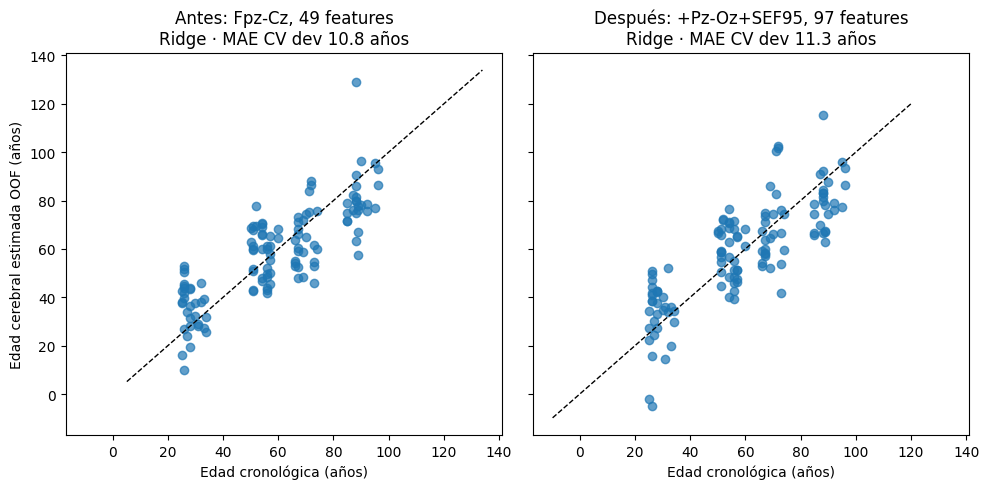

In [8]:
%matplotlib inline
# train.py fuerza matplotlib.use("Agg") al importarse (para loguear a mlflow sin display);
# se reactiva aquí el backend inline para que el notebook muestre la figura.

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

for ax, oof_dict, res_df, title in (
        (axes[0], oof_before, res_before, "Antes: Fpz-Cz, 49 features"),
        (axes[1], oof_after, res_after, "Después: +Pz-Oz+SEF95, 97 features")):
    y_true, y_pred = oof_dict["ridge"]
    mae = res_df.loc[res_df["modelo"] == "ridge", "mae_cv_dev"].iloc[0]
    ax.scatter(y_true, y_pred, alpha=0.7)
    lims = [min(y_true.min(), y_pred.min()) - 5, max(y_true.max(), y_pred.max()) + 5]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlabel("Edad cronológica (años)")
    ax.set_title(f"{title}\nRidge · MAE CV dev {mae:.1f} años")
axes[0].set_ylabel("Edad cerebral estimada OOF (años)")
fig.tight_layout()
plt.show()


## 5 · Resultado

| Conjunto | Modelo | MAE CV dev (defendible) | R² | corr(BAI, edad) |
|---|---|---:|---:|---:|
| Antes — Fpz-Cz, 49 feats | Ridge | **10.8** | 0.65 | −0.49 |
| Después — +Pz-Oz+SEF95, 97 feats | Ridge | **11.3** (peor) | 0.61 | −0.37 |

*(los números exactos de esta corrida están en la tabla `comparison` de la celda
anterior; pueden variar en la tercera cifra decimal entre corridas por el orden de
punto flotante, no por aleatoriedad — no hay componentes estocásticos sin semilla fija
en este pipeline).*

**Agregar el segundo canal y SEF95 no ayudó — empeoró el MAE de validación cruzada en
medio año**, pese a que ambas señales son fisiológicamente razonables (Pz-Oz aporta
región parieto-occipital, SEF95 es un marcador de envejecimiento cortical bien
establecido). Esto reproduce exactamente el diagnóstico del otro equipo: con 62 sujetos
de desarrollo, duplicar las columnas (49→97) le da a cualquier modelo más formas de
ajustar ruido en la validación cruzada — es un problema de **varianza, no de sesgo**. Es
consistente también con que el propio experimento del otro repo (32 columnas, mucho más
compacto) apenas moviera la cifra defendible de CV (10,36 → 10,43) pese a ganar en el
número de test, que ellos mismos marcan como optimista por reconsultarse muchas veces.

## 6 · Conclusión y próximos pasos

- **No se adopta** la combinación Pz-Oz + SEF95 tal como se probó aquí (concatenación
  simple de todas las bandas por estadio de los dos canales). El pipeline de producción
  sigue en Fpz-Cz solo, 49 features, Ridge — el código del segundo canal queda en el
  repo (apagado por diseño: si el EDF no trae Pz-Oz, simplemente no se calculan esas
  columnas) por si vale la pena retomarlo con menos columnas o más regularización.
- **No se exploran redes neuronales** para esta regresión — ya lo hizo el equipo
  (`Experimentos/Sebastian/README.md`) sobre ocho familias de modelos, con el mismo
  resultado de varianza. No hace falta repetirlo.
- Si se quiere insistir con el segundo canal, la vía más barata es *reducir* — no sumar —
  columnas: por ejemplo, solo la banda NREM global de Pz-Oz + SEF95 (12 columnas nuevas
  en vez de 48), o una búsqueda de `alpha` de Ridge más agresiva para compensar la
  dimensionalidad extra. Ninguna de las dos se probó en este notebook.
- El resto del plan de mejora del modelo (calibración del sesgo del BAI, intervalo de
  predicción) sigue siendo el camino más prometedor y no se tocó aquí.

## Referencias

- Repo de experimentos del equipo:
  [`juancasas1996/MAIA_Proyecto_Desarrollo_De_Soluciones`](https://github.com/juancasas1996/MAIA_Proyecto_Desarrollo_De_Soluciones),
  carpeta `Experimentos/Sebastian/` (partición fija, comparación de 8 familias de modelos,
  experimento de dos canales).
- `docs/API_CONTRACT.md` y `backend/README.md` de este repo — contrato de features que
  consume `backend/app/model/predictor.py`.
